In [6]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

RACINE = Path.cwd()
while not (RACINE / "src").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
sys.path.append(str(RACINE / "src"))

tableau = pd.read_csv(RACINE / "reports" / "comparaison_modeles.csv", index_col=0)
pred = pd.read_parquet(RACINE / "reports" / "predictions_validation.parquet")
tableau

,MAE (€),MAPE (%),Erreur médiane (%),Part à ±10 % (%)
Baseline (médiane code postal),46960.4,30.0,18.8,28.4
Régression linéaire (Ridge),42806.5,26.7,16.4,31.9
Random Forest,32316.0,19.2,11.6,44.9
LightGBM,32238.6,19.3,11.4,45.2


In [7]:
f = pd.read_parquet(RACINE / "data" / "processed" / "ventes_features.parquet")
f.loc[[19155, 19152, 15563], ["id_mutation", "date_mutation", "adresse_numero", "adresse_nom_voie", "valeur_fonciere", "surface_reelle_bati", "prix_m2"]]

,id_mutation,date_mutation,adresse_numero,adresse_nom_voie,valeur_fonciere,surface_reelle_bati,prix_m2
19155,2024-410564,2024-12-24,9.0,RUE ANDRE MICHEL,87910.0,141.0,623.475177
19152,2024-410553,2024-12-26,9.0,RUE ANDRE MICHEL,87160.0,138.0,631.594203
15563,2024-394417,2024-01-31,32.0,AV GEORGES CLEMENCEAU,114000.0,183.0,622.950820


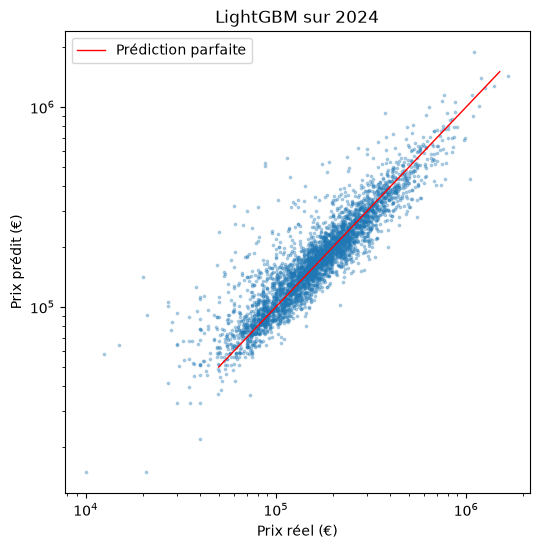

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pred["reel"], pred["LightGBM"], s=3, alpha=0.3)
limite = [50_000, 1_500_000]
ax.plot(limite, limite, color="red", linewidth=1, label="Prédiction parfaite")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Prix réel (€)")
ax.set_ylabel("Prix prédit (€)")
ax.set_title("LightGBM sur 2024")
ax.legend()
plt.show()

In [9]:
pred["erreur_relative"] = (pred["LightGBM"] - pred["reel"]).abs() / pred["reel"]
pred["tranche_surface"] = pd.cut(pred["surface_reelle_bati"], [0, 30, 50, 80, 120, 400])

for colonne in ["type_local", "code_postal", "tranche_surface"]:
    print(pred.groupby(colonne, observed=True)["erreur_relative"].agg(["median", "count"]).round(3), "\n")

pred.sort_values("erreur_relative", ascending=False).head(10)

             median  count
type_local                
Appartement   0.112   3502
Maison        0.133    389 

             median  count
code_postal               
34000         0.114   1356
34070         0.111   1237
34080         0.124    531
34090         0.110    767 

                 median  count
tranche_surface               
(0, 30]           0.105    767
(30, 50]          0.101    968
(50, 80]          0.119   1407
(80, 120]         0.121    606
(120, 400]        0.172    143 



,type_local,code_postal,surface_reelle_bati,dist_centre,reel,Baseline,Régression linéaire (Ridge),Random Forest,LightGBM,erreur_relative,tranche_surface
18208,Appartement,34000,32.0,1295.029962,20000.0,121518.987342,128713.393893,144002.148352,141272.307250,6.063615,"(30, 50]"
19155,Appartement,34000,141.0,502.465148,87910.0,535443.037975,404982.904546,522558.086031,521338.780154,4.930369,"(120, 400]"
19152,Appartement,34000,138.0,502.465148,87160.0,524050.632911,397461.344744,512145.899777,508110.676245,4.829631,"(120, 400]"
17602,Appartement,34000,77.0,2525.457020,60000.0,292405.063291,289079.907897,339947.467441,318996.479457,4.316608,"(50, 80]"
15563,Appartement,34000,183.0,913.965994,114000.0,694936.708861,434423.241293,576617.475910,554965.287830,3.868117,"(120, 400]"
15739,Appartement,34090,74.0,3929.066237,50000.0,272298.235294,211361.827968,258353.661131,237121.773816,3.742435,"(50, 80]"
17371,Appartement,34070,19.0,3019.916486,12500.0,55222.142857,62235.261070,56666.588085,58417.133222,3.673371,"(0, 30]"
17091,Appartement,34070,30.0,1556.009951,21000.0,87192.857143,97516.502308,70243.601902,91527.001071,3.358429,"(0, 30]"
18782,Appartement,34090,22.0,2550.745273,15000.0,80953.529412,76078.264342,65381.089677,64715.839281,3.314389,"(0, 30]"
16354,Appartement,34000,70.0,858.657532,60735.5,265822.784810,214511.501045,255132.138616,260865.966585,3.295115,"(50, 80]"


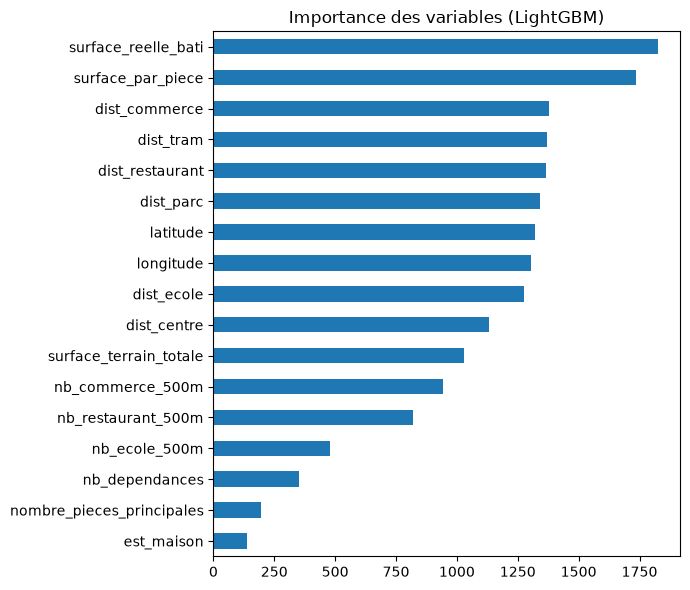

In [10]:
from train import VARIABLES

modele = joblib.load(RACINE / "models" / "lightgbm_v1.joblib")
importance = pd.Series(modele.feature_importances_, index=VARIABLES).sort_values()
importance.plot.barh(figsize=(7, 6), title="Importance des variables (LightGBM)")
plt.tight_layout()
plt.show()

In [11]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from train import CIBLE, charger, evaluer

df = charger(RACINE / "data" / "processed" / "ventes_features.parquet")
hors_test = df[df["annee"] <= 2024]
a, b = train_test_split(hors_test, test_size=0.2, random_state=42)
m = LGBMRegressor(n_estimators=600, learning_rate=0.05, random_state=42, verbose=-1)
m.fit(a[VARIABLES], a[CIBLE])
print("Découpage aléatoire :", evaluer(b["valeur_fonciere"], m.predict(b[VARIABLES]) * b["surface_reelle_bati"]))
print("Découpage temporel  :", tableau.loc["LightGBM"].to_dict())

Découpage aléatoire : {'MAE (€)': np.float64(33264.938498649026), 'MAPE (%)': np.float64(17.74569948841162), 'Erreur médiane (%)': np.float64(11.355195968931945), 'Part à ±10 % (%)': np.float64(44.42132639791937)}
Découpage temporel  : {'MAE (€)': 32238.6, 'MAPE (%)': 19.3, 'Erreur médiane (%)': 11.4, 'Part à ±10 % (%)': 45.2}
